# TS4
## Estimación Espectral con Ventanas
### Catalina Wynne

## Consigna
Comenzaremos con la generación de la siguiente señal:

$ x(k)=a0⋅sen(Ω1⋅n)+na(n) $
siendo

$ a0=2 $

$ Ω1=Ω0+fr⋅2πN $

$ Ω0=π2 $


siendo la variable aleatoria definida por la siguiente distribución de probabilidad

$ fr∼U(−2,2) $


$ na∼N(0,σ2) $

Diseñe los siguientes estimadores,  de amplitud a1


 $ a^i1=|Xiw(Ω0)|=|F{x(n)⋅wi(n)}| $


y de frecuencia Ω1


 $ Ω^i1=arg maxf{|Xiw(Ω)|} $

para cada una de las ventanas:
rectangular (sin ventana), 
flattop 
blackmanharris
otra que elija de scipy.signal.windows
Y siguiendo las siguientes consignas para su experimentación:

Considere 200 realizaciones (muestras tomadas de fr) de 1000 muestras para cada experimento. Parametrice para SNR's de 3 y 10 db (Ayuda: calibre a1
 para que la potencia de la senoidal sea 1 W). Se pide:

1) Realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada. Recuerde incluir las ventanas rectangular (sin ventana), flattop y blackmanharris y otras que considere. 


Estimación de Amplitud	 
Rectangular	 	 	 	 	 
Flat-top	 	 	 	 	 
Blackman	 	 	 	 	 
Hamming	 	 	 	 	 


Estimación de Frecuencia 
Rectangular	 	 	 	 	 
Flat-top	 	 	 	 	 
Blackman	 	 	 	 	 
Hamming	 	 	 	 	 
Ayuda: Puede calcular experimentalmente el sesgo y la varianza de un estimador:

$ a0=|Xiw(Ω0)| $

siendo

 $ sa=E{a0}−a0 $

$ va=var{a0}=E{(a0−E{a0})2} $

y pueden aproximarse cuando consideramos los valores esperados como las medias muestrales

$ E{a0}=μa=1M∑j=0M−1ajsa=μa−a0va=1M∑j=0M−1(aj−μa)2 $

Bonus:
💎 Analice el efecto del zero-padding para el estimador Ω^1
 
🤯 Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.
Visualizar los 3 histogramas juntos

### Introducción 

En este trabajo se estudia el comportamiento de distintos estimadores de amplitud y frecuencia aplicados a señales senoidales con ruido blanco gaussiano aditivo. 

La señal analizada posee una frecuencia aleatoria distribuida uniformemente alrededor de una frecuencia central, que permite evaluar el comportamiento de los estimadores frente a pequeñas variaciones espectrales. 

A partir de la DFT, se estima la amplitud de la senoidal y la frecuencia dominante, utilizando diferentes funciones de ventaneo.
Las utilizadas en este trabajo son, Rectangular, Flattop, Blackman-Harris y Hamming.

El objetivo principal es comparar experimentalmente el sesgo y la varianza de cada estimador para distintos niveles de SNR.

Además, se estudia el efecto del zero-padding sobre la estimación frecuencial y la resolución espectral de la DFT.

## Definición de la señal 

La señal utilizada en este trabajo corresponde a una senoidal cuya freciencia presenta una perturbación aleatoria:
$ fr∼U(−2,2) $

Esto implica que cada realización posee una frecuencia ligeramente distinta.

Además, se agrega ruido blanco gaussiano:
$ na∼N(0,σ2) $

Donde la varianza depende del SNR deseado, en nuestro caso 3 o 10 dB.

La amplitud de la señal se fija como:
$ a0 = \sqrt(2) $

de forma que la potencia de la senoidal resulte unitaria:
$ P= a0^2/2 = 1W $


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

def mi_funcion_sen(ao, dc, ff, ph, N, fs):
    ts = 1 / fs
    tt = np.arange(0, N) * ts
    xx = dc + ao * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

#%%
'------- PARAMETROS-----------'
ao = np.sqrt(2) # para que la potencia sea 1 W
dc = 0
ph = 0 
N = 1000
L = N * 10
fs = 1000
ff = fs/N
df = fs/N # resolucion espectral 
df_zp = fs/L
R = 200
Ts = 1/fs

## Generación de realizaciones

Para el análisis estadístico se generaron 200 realizaciones independientes de la señal, cada una con una perturbación aleatoria distinta en frecuencia y una realización diferente de ruido blanco gaussiano.

Esto permite calcular experimentalmente el sesgo y la varianza de los estimadores.

In [2]:
tt,xx = mi_funcion_sen(ao, dc,ff,ph,N,fs)
 
fr = np.random.uniform(-2,2,R)
omega_0 = N/4
omega_1 = omega_0 + fr 
f1 = omega_1 * df

# MATRIZ RxN
N_vector = tt.reshape((1,N))
matriz_N = np.tile(N_vector, ((R,1)))
matriz_f1 = (np.tile(f1, ((N,1)))).T

matriz_senoidal = (ao * np.sin(2*np.pi*matriz_N*matriz_f1))


## Señal original y espectro 

A continuación se muestran las distintas realizaciones generadas y sus respectivos espectros calculados mediante la FFT.

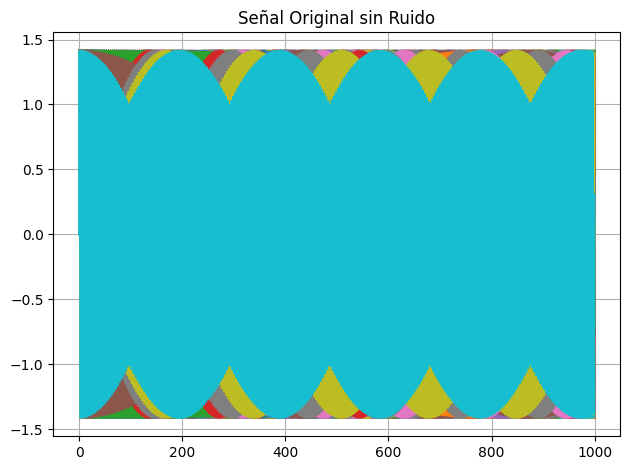

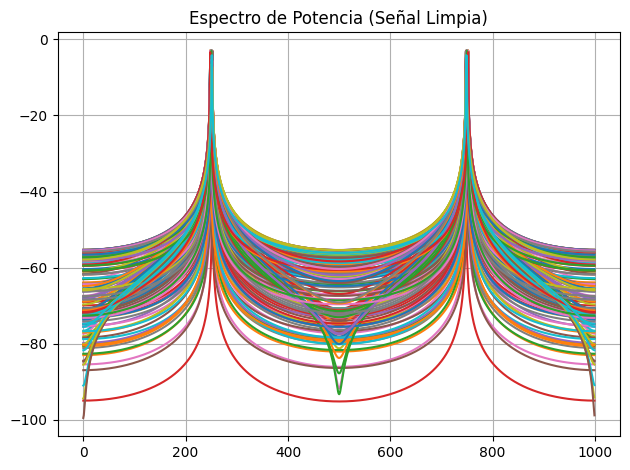

In [3]:
plt.figure()
plt.plot(matriz_senoidal.T) 
plt.title('Señal Original sin Ruido')
plt.grid(True)
plt.tight_layout()
plt.show()

MM = np.fft.fft(matriz_senoidal,  axis=1)/N
MMmod = np.abs(MM) # MODULO
MMesp_db = 20 * np.log10(MMmod + 1e-12 ) # ESPECTRO POTENCIA 

plt.figure()
plt.plot(MMesp_db.T) 
plt.title('Espectro de Potencia (Señal Limpia)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Análisis de la señal y del espectro
La señal corresponde a una senoidal cuya frecuencia cambia aleatoriamente en cada realización, provocando que los espectros no queden exactamente centrado en un único bin de la FFT, sino que aparezca desparramo espectral.

En la representación temporal puedo observar que todas las señales mantienen la misma amplitud aunque presenten variaciones de frecuencia debido a esta perturbación aleatoria que se da mediante la fr.

En la representación frecuencial los espectros muestran que la energía está concentrada alrededor de la frecuencia central, aunque está distribuida entre varios bins debido a que la frecuencia real no coincide con una frecuencia natural de la FFT.

## Estimación para distintos SNR

Para evaluar el desempeño de los estimadores consideré dos niveles de relación señal a ruido : 3db y 10 db.

Para cada caso se genere nuevas realizaciones de ruido blanco gaussiano.


## Estimación para SNR = 3 dB

In [4]:
mu = 0
SNR_db = 3
sigma = np.sqrt(10**(-SNR_db/10))

ruido_blanco = np.random.normal(mu,sigma,(R,N))

x_k = matriz_senoidal + ruido_blanco

## Ventanas

In [5]:
flattop = signal.windows.flattop(N)

blackman = signal.windows.blackmanharris(N)

hamming = signal.windows.hamming(N)

## Estimación de amplitud
El estimador de amplitud se obtiene a partir del módulo de la FFT evaluada en la frecuencia dominante de la señal.

Para compensar la atenuación introducida por cada ventana, normalice utilizando la suma de los coeficientes de cada ventana.

In [6]:
# FFT señal rectangular
XX_KK = np.fft.fft(x_k, n=L, axis=1)

estimador_amplitud = 2*np.abs(XX_KK[:,L//4]) / N

# FLATTOP
x_flatt = x_k * flattop

XX_flatt = np.fft.fft(x_flatt, n=L, axis=1)

estimador_amplitud_flattop = 2*np.abs(XX_flatt[:,L//4]) / np.sum(flattop)

# BLACKMAN
x_blackman = x_k * blackman

XX_blackman = np.fft.fft(x_blackman, n=L, axis=1)

estimador_amplitud_blackman = 2*np.abs(XX_blackman[:,L//4]) / np.sum(blackman)

# HAMMING
x_hamming = x_k * hamming

XX_hamming = np.fft.fft(x_hamming, n=L, axis=1)

estimador_amplitud_hamming = 2*np.abs(XX_hamming[:,L//4]) / np.sum(hamming)

## Histogramas de amplitud 

Los histogramas me permiten visualizar la dispersión de cada estimador y comparar el efecto de las distintas ventanas sobre la misma estimación de amplitud.

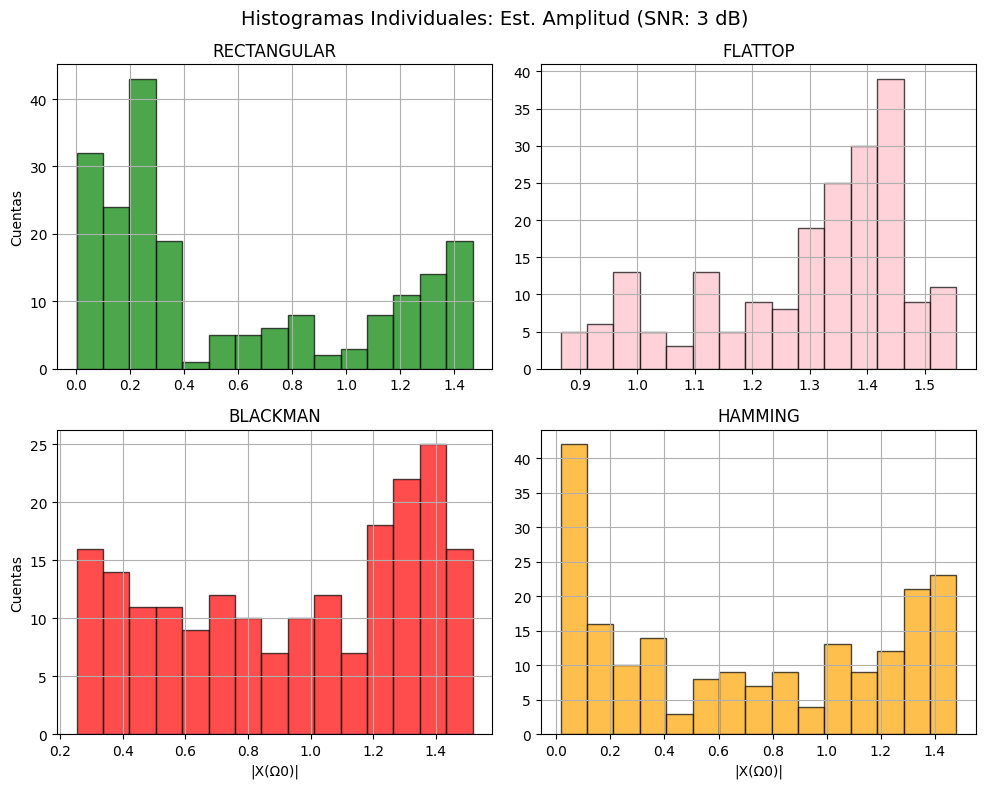

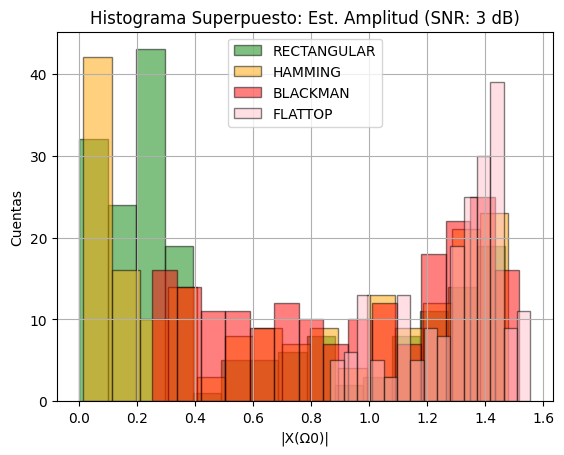

In [7]:
# --- SUBPLOT 2x2 ESTIMADOR AMPLITUD ---
fig_a, axs_a = plt.subplots(2, 2, figsize=(10, 8))
fig_a.suptitle(f'Histogramas Individuales: Est. Amplitud (SNR: {SNR_db} dB)', fontsize=14)

axs_a[0, 0].hist(estimador_amplitud, bins=15, color='green', edgecolor='black', alpha=0.7)
axs_a[0, 0].set_title('RECTANGULAR')
axs_a[0, 0].set_ylabel('Cuentas')
axs_a[0, 0].grid(True)

axs_a[0, 1].hist(estimador_amplitud_flattop, bins=15, color='pink', edgecolor='black', alpha=0.7)
axs_a[0, 1].set_title('FLATTOP')
axs_a[0, 1].grid(True)

axs_a[1, 0].hist(estimador_amplitud_blackman, bins=15, color='red', edgecolor='black', alpha=0.7)
axs_a[1, 0].set_title('BLACKMAN')
axs_a[1, 0].set_xlabel('|X(Ω0)|')
axs_a[1, 0].set_ylabel('Cuentas')
axs_a[1, 0].grid(True)

axs_a[1, 1].hist(estimador_amplitud_hamming, bins=15, color='orange', edgecolor='black', alpha=0.7)
axs_a[1, 1].set_title('HAMMING')
axs_a[1, 1].set_xlabel('|X(Ω0)|')
axs_a[1, 1].grid(True)

plt.tight_layout()
plt.show()
## GRAFICOS ESTIMADOR AMPLITUD TODOS JUNTOS
plt.figure()
plt.hist(estimador_amplitud, bins=15, color='green', edgecolor='black', label='RECTANGULAR', alpha=0.5) 
plt.hist(estimador_amplitud_hamming, bins=15, color ='orange', edgecolor='black', label ='HAMMING', alpha=0.5) 
plt.hist(estimador_amplitud_blackman, bins=15, color='red', edgecolor='black', label ='BLACKMAN', alpha=0.5) 
plt.hist(estimador_amplitud_flattop, bins=15, color='pink', edgecolor='black', label='FLATTOP', alpha=0.5) 

plt.title(f'Histograma Superpuesto: Est. Amplitud (SNR: {SNR_db} dB)')
plt.xlabel('|X(Ω0)|')
plt.ylabel('Cuentas')
plt.legend()
plt.grid(True)
plt.show()


La ventana Flat-top presenta la mejor estimación de amplitud, ya que es una ventana creada para disminuir errores de amplitud en señales senoidales. Por el contrario, la ventana rectangular presenta mayor dispersión y mayor tendecia al leakeage espectral debido a que sus lóbulos secundarios son altos. Las ventanas Hamming y Blackman-Harris reducen sus lóbulos secundarios considerablente respecto a la rectangular, disminuyendo el leakage espectral. Introducen una mayor atenuación del pico espectral y por eso tienen un error mayor en amplitud respecto de la Flat-top.

A medida que el SNR va aumentando se produce una concentración al rededor del valor real de amplitud lo que indica que hay una reducción de la varianza de los estimadores.

## Estimación de la frecuencia
La estimación frecuencial se realiza localizando el bin de maxima energía en la FFT.

Inicialmente analice el comportamiento sin usar zero padding, por lo que la resolución frecuencia esta dada por la siguiente ecuación:
$Δf=fs/N $
    

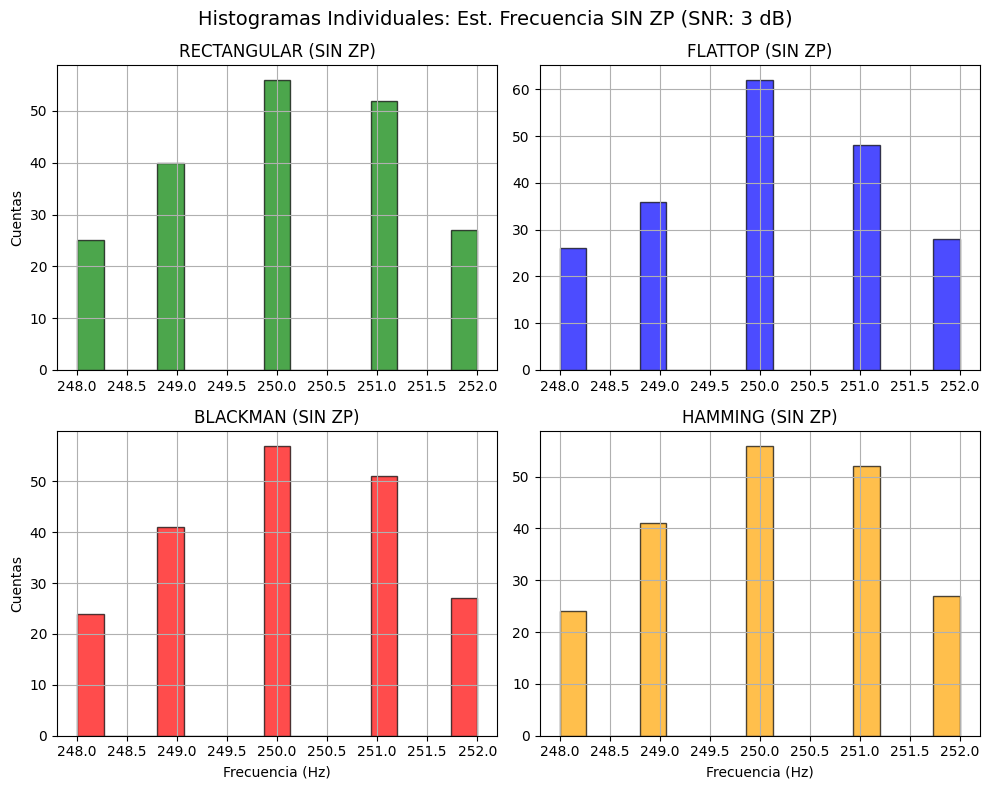

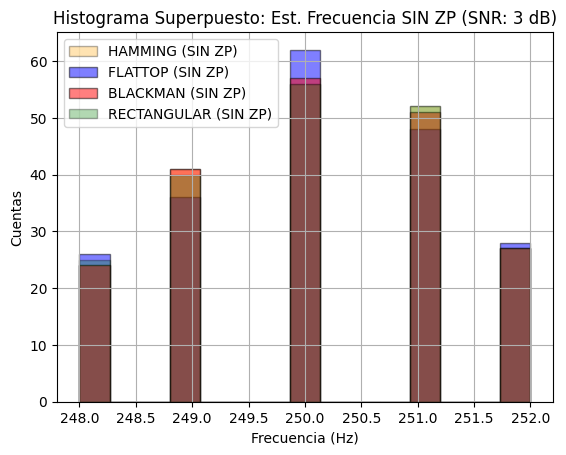

In [8]:
XX_KK_sin = np.fft.fft(x_k, n=N, axis=1)
XX_flatt_sin = np.fft.fft(x_flatt, n=N, axis=1)
XX_blackman_sin = np.fft.fft(x_blackman, n=N, axis=1)
XX_hamming_sin = np.fft.fft(x_hamming, n=N, axis=1)

est_frec_rect_sin = np.argmax(np.abs(XX_KK_sin)[:,:N//2], axis=1) * df
est_frec_flatt_sin = np.argmax(np.abs(XX_flatt_sin)[:,:N//2], axis=1) * df
est_frec_blackman_sin = np.argmax(np.abs(XX_blackman_sin)[:,:N//2], axis=1) * df
est_frec_hamming_sin = np.argmax(np.abs(XX_hamming_sin)[:,:N//2], axis=1) * df

# --- SUBPLOT 2x2 ESTIMADOR FRECUENCIA (SIN ZP) ---
fig_f_sin, axs_f_sin = plt.subplots(2, 2, figsize=(10, 8))
fig_f_sin.suptitle(f'Histogramas Individuales: Est. Frecuencia SIN ZP (SNR: {SNR_db} dB)', fontsize=14)

axs_f_sin[0, 0].hist(est_frec_rect_sin, bins=15, color='green', edgecolor='black', alpha=0.7)
axs_f_sin[0, 0].set_title('RECTANGULAR (SIN ZP)')
axs_f_sin[0, 0].set_ylabel('Cuentas')
axs_f_sin[0, 0].grid(True)

axs_f_sin[0, 1].hist(est_frec_flatt_sin, bins=15, color='blue', edgecolor='black', alpha=0.7)
axs_f_sin[0, 1].set_title('FLATTOP (SIN ZP)')
axs_f_sin[0, 1].grid(True)

axs_f_sin[1, 0].hist(est_frec_blackman_sin, bins=15, color='red', edgecolor='black', alpha=0.7)
axs_f_sin[1, 0].set_title('BLACKMAN (SIN ZP)')
axs_f_sin[1, 0].set_xlabel('Frecuencia (Hz)')
axs_f_sin[1, 0].set_ylabel('Cuentas')
axs_f_sin[1, 0].grid(True)

axs_f_sin[1, 1].hist(est_frec_hamming_sin, bins=15, color='orange', edgecolor='black', alpha=0.7)
axs_f_sin[1, 1].set_title('HAMMING (SIN ZP)')
axs_f_sin[1, 1].set_xlabel('Frecuencia (Hz)')
axs_f_sin[1, 1].grid(True)

plt.tight_layout()
plt.show()

# --- GRAFICOS ESTIMADOR FRECUENCIA TODOS JUNTOS (SIN ZP) ---
plt.figure()
plt.hist(est_frec_hamming_sin, bins=15, color='orange', edgecolor='black', label='HAMMING (SIN ZP)', alpha=0.3) 
plt.hist(est_frec_flatt_sin, bins=15, color='blue', edgecolor='black', label='FLATTOP (SIN ZP)', alpha=0.5) 
plt.hist(est_frec_blackman_sin, bins=15, color='red',  edgecolor='black', label = 'BLACKMAN (SIN ZP)', alpha = 0.5) 
plt.hist(est_frec_rect_sin, bins=15, color='green', edgecolor='black', label='RECTANGULAR (SIN ZP)', alpha=0.3) 
plt.title(f'Histograma Superpuesto: Est. Frecuencia SIN ZP (SNR: {SNR_db} dB)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Cuentas')
plt.legend()
plt.grid(True)
plt.show()

Las ventanas con lóbulos principales más angostos estan mejor posicionadas frente a la frecuencia, aquellas que tienen lóbulos más anchos priorizan reducir el leakage antes que la resolución de la frecuencia.

Debido a esto, las diferencias entre ventanas en frecuencia son menores que en amplitud.

## Con Zero Padding
El zero padding consiste en agregar ceros al final de la señal antes de calcular la FFT.
Esto incrementa la cantidad de puntos espectrales y reduce el espaciamiento entre bins:
$ Δf = fs/L $

permitiendo una estimación mas concreta de la frecuencia dominante.
Sin embargo, no agrega información nueva ni mejora la resolución espectral real 

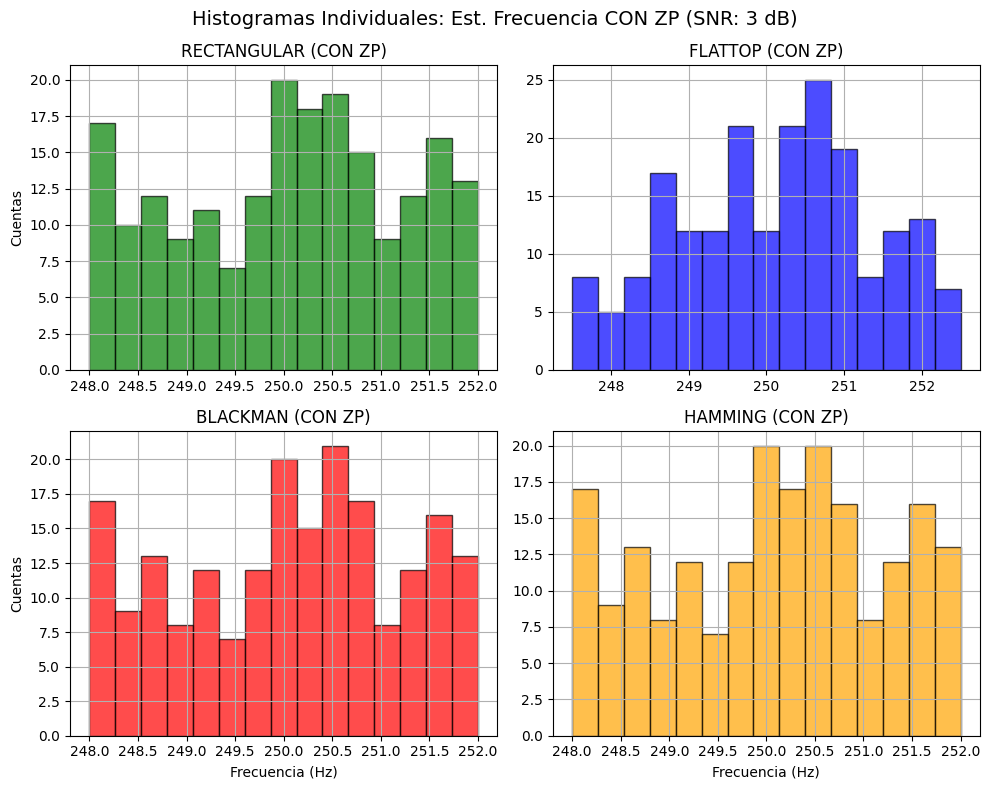

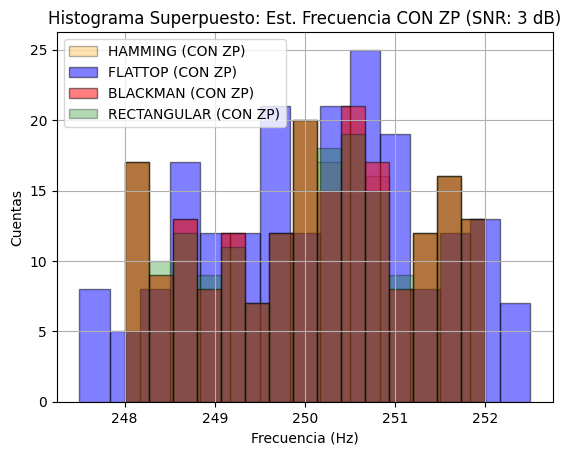

In [9]:
'----RECTANGULAR-----'
XX_KK_mod = np.abs(XX_KK)
estimador_frecuencia = np.argmax(XX_KK_mod[:,:L//2], axis=1)
estimador_frecuencia_rectangular_zp = estimador_frecuencia*df_zp

'----FLATTOP-----'
XX_flat_mod = np.abs(XX_flatt)
estimador_frecuencia_flattop = np.argmax(XX_flat_mod[:,:L//2], axis=1)
nuevo_estimador = estimador_frecuencia_flattop*df_zp

'----BLACKMAN-----'
XX_blackman_mod = np.abs(XX_blackman)
estimador_frecuencia_blackman = np.argmax(XX_blackman_mod[:,:L//2], axis=1)

'----HAMMING-----'
XX_hamming_mod = np.abs(XX_hamming)
estimador_frecuencia_hamming = np.argmax(XX_hamming_mod[:,:L//2], axis=1)

# --- SUBPLOT 2x2 ESTIMADOR FRECUENCIA (CON ZP) ---
fig_f, axs_f = plt.subplots(2, 2, figsize=(10, 8))
fig_f.suptitle(f'Histogramas Individuales: Est. Frecuencia CON ZP (SNR: {SNR_db} dB)', fontsize=14)

axs_f[0, 0].hist(estimador_frecuencia_rectangular_zp, bins=15, color='green', edgecolor='black', alpha=0.7)
axs_f[0, 0].set_title('RECTANGULAR (CON ZP)')
axs_f[0, 0].set_ylabel('Cuentas')
axs_f[0, 0].grid(True)

axs_f[0, 1].hist(nuevo_estimador, bins=15, color='blue', edgecolor='black', alpha=0.7)
axs_f[0, 1].set_title('FLATTOP (CON ZP)')
axs_f[0, 1].grid(True)

axs_f[1, 0].hist(estimador_frecuencia_blackman*df_zp, bins=15, color='red', edgecolor='black', alpha=0.7)
axs_f[1, 0].set_title('BLACKMAN (CON ZP)')
axs_f[1, 0].set_xlabel('Frecuencia (Hz)')
axs_f[1, 0].set_ylabel('Cuentas')
axs_f[1, 0].grid(True)

axs_f[1, 1].hist(estimador_frecuencia_hamming*df_zp, bins=15, color='orange', edgecolor='black', alpha=0.7)
axs_f[1, 1].set_title('HAMMING (CON ZP)')
axs_f[1, 1].set_xlabel('Frecuencia (Hz)')
axs_f[1, 1].grid(True)

plt.tight_layout()
plt.show()

## GRAFICOS ESTIMADOR FRECUENCIA TODOS JUNTOS (CON ZP)
plt.figure()
plt.hist(estimador_frecuencia_hamming*df_zp, bins=15, color='orange', edgecolor='black', label='HAMMING (CON ZP)', alpha=0.3) 
plt.hist(nuevo_estimador, bins=15, color='blue', edgecolor='black', label='FLATTOP (CON ZP)', alpha=0.5) 
plt.hist(estimador_frecuencia_blackman*df_zp, bins=15, color='red',  edgecolor='black', label = 'BLACKMAN (CON ZP)', alpha = 0.5) 
plt.hist(estimador_frecuencia_rectangular_zp, bins=15, color='green', edgecolor='black', label='RECTANGULAR (CON ZP)', alpha=0.3) 
plt.title(f'Histograma Superpuesto: Est. Frecuencia CON ZP (SNR: {SNR_db} dB)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Cuentas')
plt.legend()
plt.grid(True)
plt.show()


Las ventanas Blackman-Harris y Hamming presentan mejoras en su estabilidad frecuencial, mientras que la Flat-top mantiene mejor comportamiento en amplitud pero una resolución frecuencial menor debido al ancho de su lóbulo principal.

## Sesgo y varianza 
Para evaluar el desempeño de cada estimador calcule experimentalmente su sesgo y su varianza utilizando las medias muestreales obtenidas a partir de las 200 realizacion

In [10]:
'-----------------------SESGOS Y VARIANZAS------------------'
frec_real_hz = f1 # Array de 200 frecuencias reales

#### SESGOS Y VARIANZAS AMPLITUD
sesgo_rectangular = np.mean(estimador_amplitud) - ao 
sesgo_flattop = np.mean(estimador_amplitud_flattop) - ao 
sesgo_blackman = np.mean(estimador_amplitud_blackman) - ao 
sesgo_hamming = np.mean(estimador_amplitud_hamming) - ao 

var_a_rectangular = np.var(estimador_amplitud)
var_a_flattop = np.var(estimador_amplitud_flattop)
var_a_blackman = np.var(estimador_amplitud_blackman)
var_a_hamming = np.var(estimador_amplitud_hamming)

print(f'\n======================================================')
print(f'--- SNR {SNR_db} dB: TABLA ESTIMACIÓN DE AMPLITUD ---')
print(f'======================================================')
print(f"Rectangular -> sesgo: {sesgo_rectangular:.5f} | varianza: {var_a_rectangular:.5f}")
print(f"Flat-top    -> sesgo: {sesgo_flattop:.5f} | varianza: {var_a_flattop:.5f}")
print(f"Blackman    -> sesgo: {sesgo_blackman:.5f} | varianza: {var_a_blackman:.5f}")
print(f"Hamming     -> sesgo: {sesgo_hamming:.5f} | varianza: {var_a_hamming:.5f}")

#### SESGOS Y VARIANZAS FRECUENCIAS (SIN ZP)
sesgo_frec_rect_sin = est_frec_rect_sin - frec_real_hz
sesgo_frec_flatt_sin = est_frec_flatt_sin - frec_real_hz
sesgo_frec_blackman_sin = est_frec_blackman_sin - frec_real_hz
sesgo_frec_hamming_sin = est_frec_hamming_sin - frec_real_hz

var_f_rect_sin = np.var(est_frec_rect_sin)
var_f_flatt_sin = np.var(est_frec_flatt_sin)
var_f_blackman_sin = np.var(est_frec_blackman_sin)
var_f_hamming_sin = np.var(est_frec_hamming_sin)

print(f'\n--- SNR {SNR_db} dB: TABLA ESTIMACIÓN DE FRECUENCIA (SIN ZP) ---')
print(f"Rectangular -> sesgo: {np.mean(sesgo_frec_rect_sin):.5f} | varianza: {var_f_rect_sin:.5f}")
print(f"Flat-top    -> sesgo: {np.mean(sesgo_frec_flatt_sin):.5f} | varianza: {var_f_flatt_sin:.5f}")
print(f"Blackman    -> sesgo: {np.mean(sesgo_frec_blackman_sin):.5f} | varianza: {var_f_blackman_sin:.5f}")
print(f"Hamming     -> sesgo: {np.mean(sesgo_frec_hamming_sin):.5f} | varianza: {var_f_hamming_sin:.5f}")

#### SESGOS Y VARIANZAS FRECUENCIAS (CON ZP)
sesgo_frecuencia_rect = estimador_frecuencia_rectangular_zp - frec_real_hz
sesgo_frecuencia_flattop = nuevo_estimador - frec_real_hz
sesgo_frecuencia_blackman = (estimador_frecuencia_blackman * df_zp) - frec_real_hz
sesgo_frecuencia_hamming = (estimador_frecuencia_hamming * df_zp) - frec_real_hz

var_f_rectangular = np.var(estimador_frecuencia_rectangular_zp)
var_f_flattop = np.var(nuevo_estimador)
var_f_blackman = np.var(estimador_frecuencia_blackman * df_zp)
var_f_hamming = np.var(estimador_frecuencia_hamming * df_zp)

print(f'\n--- SNR {SNR_db} dB: TABLA ESTIMACIÓN DE FRECUENCIA (CON ZP) ---')
print(f"Rectangular -> sesgo: {np.mean(sesgo_frecuencia_rect):.5f} | varianza: {var_f_rectangular:.5f}")
print(f"Flat-top    -> sesgo: {np.mean(sesgo_frecuencia_flattop):.5f} | varianza: {var_f_flattop:.5f}")
print(f"Blackman    -> sesgo: {np.mean(sesgo_frecuencia_blackman):.5f} | varianza: {var_f_blackman:.5f}")
print(f"Hamming     -> sesgo: {np.mean(sesgo_frecuencia_hamming):.5f} | varianza: {var_f_hamming:.5f}\n")


--- SNR 3 dB: TABLA ESTIMACIÓN DE AMPLITUD ---
Rectangular -> sesgo: -0.85101 | varianza: 0.24228
Flat-top    -> sesgo: -0.11780 | varianza: 0.03072
Blackman    -> sesgo: -0.47012 | varianza: 0.15844
Hamming     -> sesgo: -0.71534 | varianza: 0.27233

--- SNR 3 dB: TABLA ESTIMACIÓN DE FRECUENCIA (SIN ZP) ---
Rectangular -> sesgo: 0.01878 | varianza: 1.49360
Flat-top    -> sesgo: 0.01878 | varianza: 1.49360
Blackman    -> sesgo: 0.01878 | varianza: 1.47360
Hamming     -> sesgo: 0.02378 | varianza: 1.47778

--- SNR 3 dB: TABLA ESTIMACIÓN DE FRECUENCIA (CON ZP) ---
Rectangular -> sesgo: 0.00028 | varianza: 1.32557
Flat-top    -> sesgo: 0.04278 | varianza: 1.55028
Blackman    -> sesgo: 0.00278 | varianza: 1.32090
Hamming     -> sesgo: 0.00228 | varianza: 1.32502



## Estimación para SNR = 10dB

In [11]:
mu = 0
SNR_db = 10
sigma = np.sqrt(10**(-SNR_db/10))

ruido_blanco = np.random.normal(mu,sigma,(R,N))

x_k = matriz_senoidal + ruido_blanco

## Ventanas

In [12]:
flattop = signal.windows.flattop(N)

blackman = signal.windows.blackmanharris(N)

hamming = signal.windows.hamming(N)

## Estimación de la amplitud

In [13]:
# FFT señal rectangular
XX_KK = np.fft.fft(x_k, n=L, axis=1)

estimador_amplitud = 2*np.abs(XX_KK[:,L//4]) / N

# FLATTOP
x_flatt = x_k * flattop

XX_flatt = np.fft.fft(x_flatt, n=L, axis=1)

estimador_amplitud_flattop = 2*np.abs(XX_flatt[:,L//4]) / np.sum(flattop)

# BLACKMAN
x_blackman = x_k * blackman

XX_blackman = np.fft.fft(x_blackman, n=L, axis=1)

estimador_amplitud_blackman = 2*np.abs(XX_blackman[:,L//4]) / np.sum(blackman)

# HAMMING
x_hamming = x_k * hamming

XX_hamming = np.fft.fft(x_hamming, n=L, axis=1)

estimador_amplitud_hamming = 2*np.abs(XX_hamming[:,L//4]) / np.sum(hamming)

## Histograma de amplitud

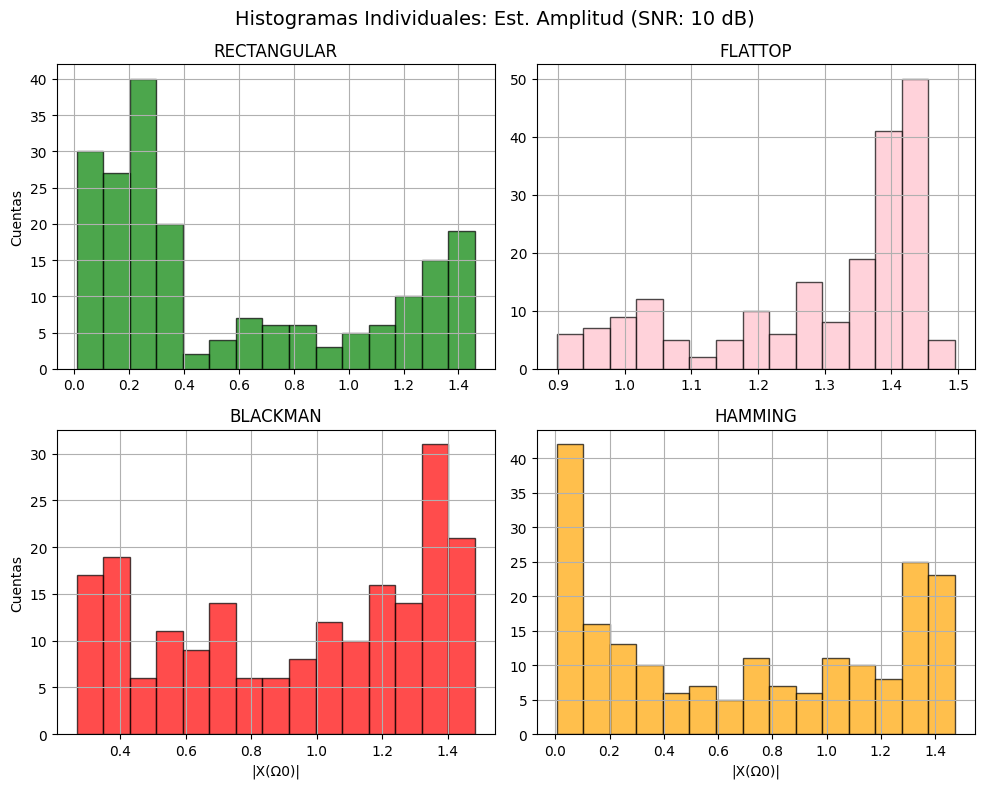

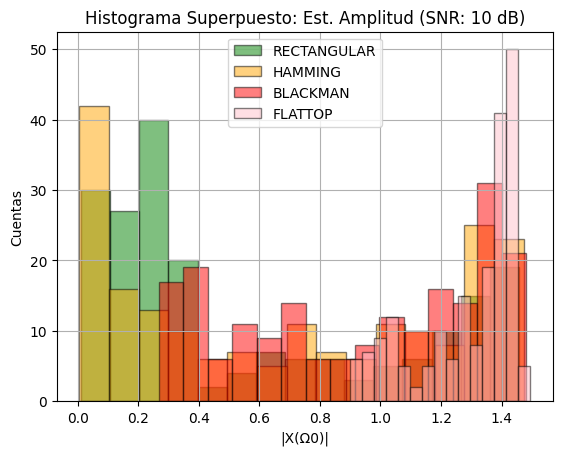

In [14]:
# --- SUBPLOT 2x2 ESTIMADOR AMPLITUD ---
fig_a, axs_a = plt.subplots(2, 2, figsize=(10, 8))
fig_a.suptitle(f'Histogramas Individuales: Est. Amplitud (SNR: {SNR_db} dB)', fontsize=14)

axs_a[0, 0].hist(estimador_amplitud, bins=15, color='green', edgecolor='black', alpha=0.7)
axs_a[0, 0].set_title('RECTANGULAR')
axs_a[0, 0].set_ylabel('Cuentas')
axs_a[0, 0].grid(True)

axs_a[0, 1].hist(estimador_amplitud_flattop, bins=15, color='pink', edgecolor='black', alpha=0.7)
axs_a[0, 1].set_title('FLATTOP')
axs_a[0, 1].grid(True)

axs_a[1, 0].hist(estimador_amplitud_blackman, bins=15, color='red', edgecolor='black', alpha=0.7)
axs_a[1, 0].set_title('BLACKMAN')
axs_a[1, 0].set_xlabel('|X(Ω0)|')
axs_a[1, 0].set_ylabel('Cuentas')
axs_a[1, 0].grid(True)

axs_a[1, 1].hist(estimador_amplitud_hamming, bins=15, color='orange', edgecolor='black', alpha=0.7)
axs_a[1, 1].set_title('HAMMING')
axs_a[1, 1].set_xlabel('|X(Ω0)|')
axs_a[1, 1].grid(True)

plt.tight_layout()
plt.show()
## GRAFICOS ESTIMADOR AMPLITUD TODOS JUNTOS
plt.figure()
plt.hist(estimador_amplitud, bins=15, color='green', edgecolor='black', label='RECTANGULAR', alpha=0.5) 
plt.hist(estimador_amplitud_hamming, bins=15, color ='orange', edgecolor='black', label ='HAMMING', alpha=0.5) 
plt.hist(estimador_amplitud_blackman, bins=15, color='red', edgecolor='black', label ='BLACKMAN', alpha=0.5) 
plt.hist(estimador_amplitud_flattop, bins=15, color='pink', edgecolor='black', label='FLATTOP', alpha=0.5) 

plt.title(f'Histograma Superpuesto: Est. Amplitud (SNR: {SNR_db} dB)')
plt.xlabel('|X(Ω0)|')
plt.ylabel('Cuentas')
plt.legend()
plt.grid(True)
plt.show()


## Estimación de frecuencia

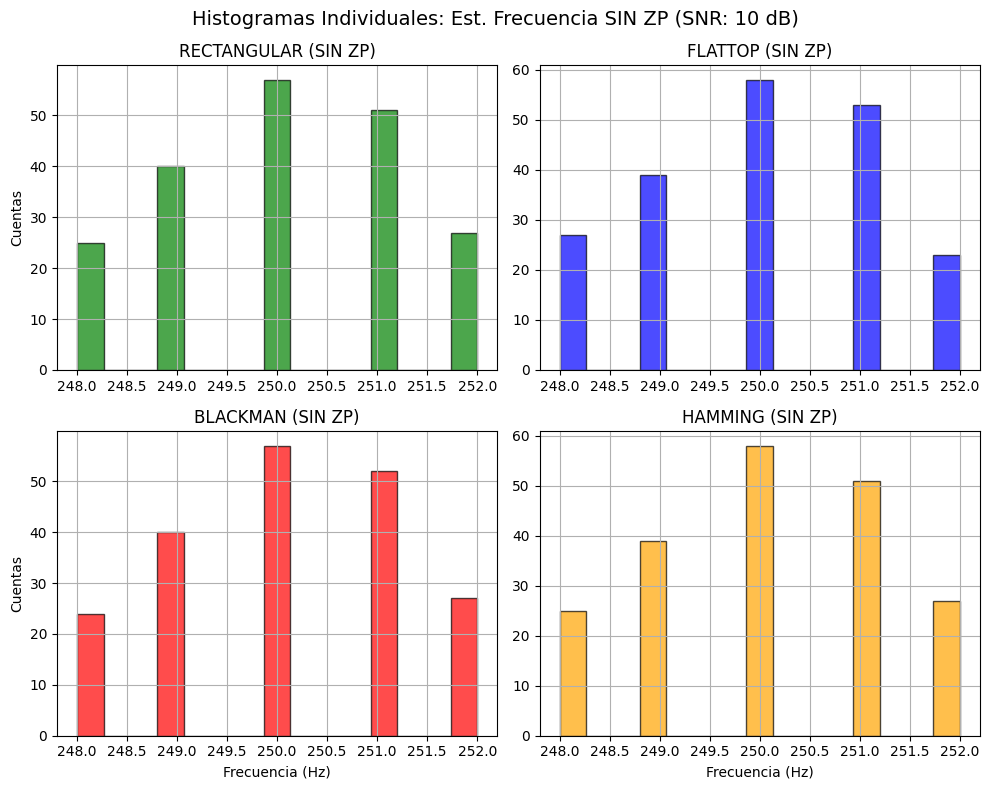

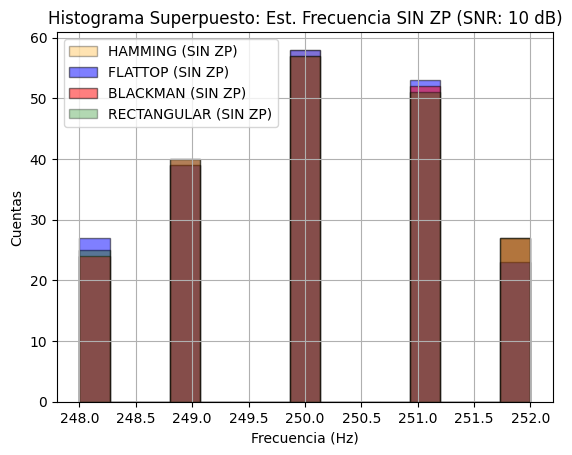

In [15]:
XX_KK_sin = np.fft.fft(x_k, n=N, axis=1)
XX_flatt_sin = np.fft.fft(x_flatt, n=N, axis=1)
XX_blackman_sin = np.fft.fft(x_blackman, n=N, axis=1)
XX_hamming_sin = np.fft.fft(x_hamming, n=N, axis=1)

est_frec_rect_sin = np.argmax(np.abs(XX_KK_sin)[:,:N//2], axis=1) * df
est_frec_flatt_sin = np.argmax(np.abs(XX_flatt_sin)[:,:N//2], axis=1) * df
est_frec_blackman_sin = np.argmax(np.abs(XX_blackman_sin)[:,:N//2], axis=1) * df
est_frec_hamming_sin = np.argmax(np.abs(XX_hamming_sin)[:,:N//2], axis=1) * df

# --- SUBPLOT 2x2 ESTIMADOR FRECUENCIA (SIN ZP) ---
fig_f_sin, axs_f_sin = plt.subplots(2, 2, figsize=(10, 8))
fig_f_sin.suptitle(f'Histogramas Individuales: Est. Frecuencia SIN ZP (SNR: {SNR_db} dB)', fontsize=14)

axs_f_sin[0, 0].hist(est_frec_rect_sin, bins=15, color='green', edgecolor='black', alpha=0.7)
axs_f_sin[0, 0].set_title('RECTANGULAR (SIN ZP)')
axs_f_sin[0, 0].set_ylabel('Cuentas')
axs_f_sin[0, 0].grid(True)

axs_f_sin[0, 1].hist(est_frec_flatt_sin, bins=15, color='blue', edgecolor='black', alpha=0.7)
axs_f_sin[0, 1].set_title('FLATTOP (SIN ZP)')
axs_f_sin[0, 1].grid(True)

axs_f_sin[1, 0].hist(est_frec_blackman_sin, bins=15, color='red', edgecolor='black', alpha=0.7)
axs_f_sin[1, 0].set_title('BLACKMAN (SIN ZP)')
axs_f_sin[1, 0].set_xlabel('Frecuencia (Hz)')
axs_f_sin[1, 0].set_ylabel('Cuentas')
axs_f_sin[1, 0].grid(True)

axs_f_sin[1, 1].hist(est_frec_hamming_sin, bins=15, color='orange', edgecolor='black', alpha=0.7)
axs_f_sin[1, 1].set_title('HAMMING (SIN ZP)')
axs_f_sin[1, 1].set_xlabel('Frecuencia (Hz)')
axs_f_sin[1, 1].grid(True)

plt.tight_layout()
plt.show()

# --- GRAFICOS ESTIMADOR FRECUENCIA TODOS JUNTOS (SIN ZP) ---
plt.figure()
plt.hist(est_frec_hamming_sin, bins=15, color='orange', edgecolor='black', label='HAMMING (SIN ZP)', alpha=0.3) 
plt.hist(est_frec_flatt_sin, bins=15, color='blue', edgecolor='black', label='FLATTOP (SIN ZP)', alpha=0.5) 
plt.hist(est_frec_blackman_sin, bins=15, color='red',  edgecolor='black', label = 'BLACKMAN (SIN ZP)', alpha = 0.5) 
plt.hist(est_frec_rect_sin, bins=15, color='green', edgecolor='black', label='RECTANGULAR (SIN ZP)', alpha=0.3) 
plt.title(f'Histograma Superpuesto: Est. Frecuencia SIN ZP (SNR: {SNR_db} dB)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Cuentas')
plt.legend()
plt.grid(True)
plt.show()

## Estimación de la frecuencia con zero padding

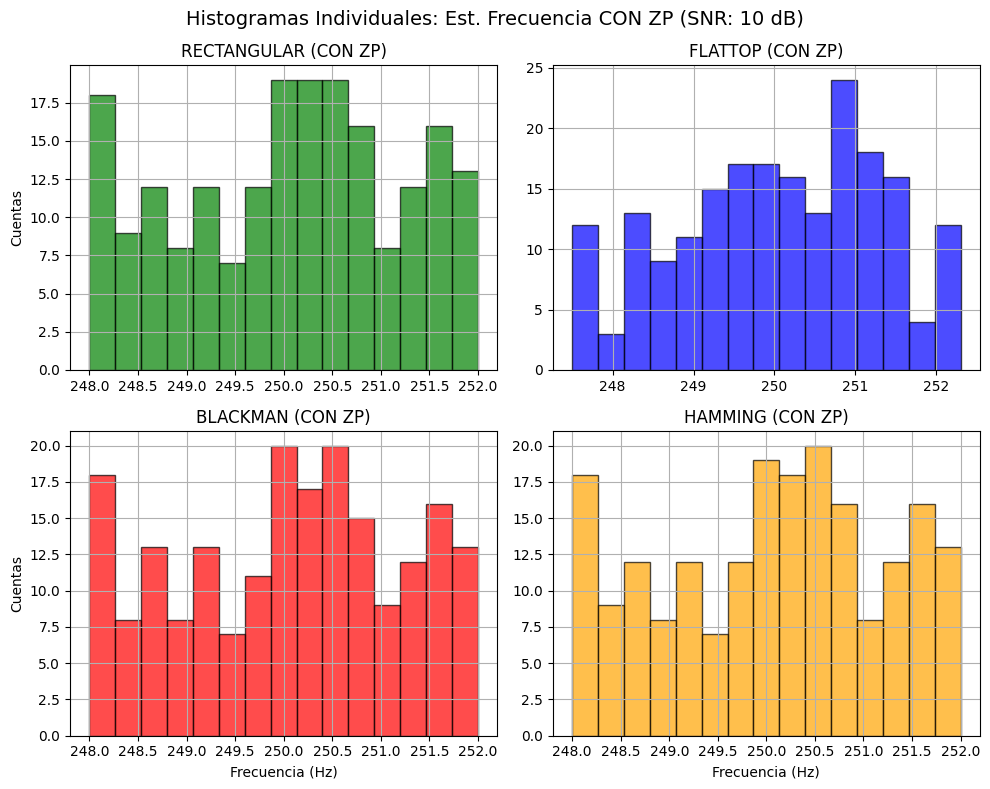

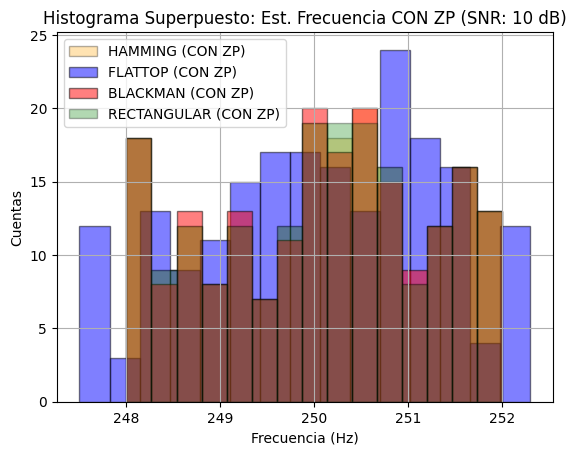

In [16]:
'----RECTANGULAR-----'
XX_KK_mod = np.abs(XX_KK)
estimador_frecuencia = np.argmax(XX_KK_mod[:,:L//2], axis=1)
estimador_frecuencia_rectangular_zp = estimador_frecuencia*df_zp

'----FLATTOP-----'
XX_flat_mod = np.abs(XX_flatt)
estimador_frecuencia_flattop = np.argmax(XX_flat_mod[:,:L//2], axis=1)
nuevo_estimador = estimador_frecuencia_flattop*df_zp

'----BLACKMAN-----'
XX_blackman_mod = np.abs(XX_blackman)
estimador_frecuencia_blackman = np.argmax(XX_blackman_mod[:,:L//2], axis=1)

'----HAMMING-----'
XX_hamming_mod = np.abs(XX_hamming)
estimador_frecuencia_hamming = np.argmax(XX_hamming_mod[:,:L//2], axis=1)

# --- SUBPLOT 2x2 ESTIMADOR FRECUENCIA (CON ZP) ---
fig_f, axs_f = plt.subplots(2, 2, figsize=(10, 8))
fig_f.suptitle(f'Histogramas Individuales: Est. Frecuencia CON ZP (SNR: {SNR_db} dB)', fontsize=14)

axs_f[0, 0].hist(estimador_frecuencia_rectangular_zp, bins=15, color='green', edgecolor='black', alpha=0.7)
axs_f[0, 0].set_title('RECTANGULAR (CON ZP)')
axs_f[0, 0].set_ylabel('Cuentas')
axs_f[0, 0].grid(True)

axs_f[0, 1].hist(nuevo_estimador, bins=15, color='blue', edgecolor='black', alpha=0.7)
axs_f[0, 1].set_title('FLATTOP (CON ZP)')
axs_f[0, 1].grid(True)

axs_f[1, 0].hist(estimador_frecuencia_blackman*df_zp, bins=15, color='red', edgecolor='black', alpha=0.7)
axs_f[1, 0].set_title('BLACKMAN (CON ZP)')
axs_f[1, 0].set_xlabel('Frecuencia (Hz)')
axs_f[1, 0].set_ylabel('Cuentas')
axs_f[1, 0].grid(True)

axs_f[1, 1].hist(estimador_frecuencia_hamming*df_zp, bins=15, color='orange', edgecolor='black', alpha=0.7)
axs_f[1, 1].set_title('HAMMING (CON ZP)')
axs_f[1, 1].set_xlabel('Frecuencia (Hz)')
axs_f[1, 1].grid(True)

plt.tight_layout()
plt.show()

## GRAFICOS ESTIMADOR FRECUENCIA TODOS JUNTOS (CON ZP)
plt.figure()
plt.hist(estimador_frecuencia_hamming*df_zp, bins=15, color='orange', edgecolor='black', label='HAMMING (CON ZP)', alpha=0.3) 
plt.hist(nuevo_estimador, bins=15, color='blue', edgecolor='black', label='FLATTOP (CON ZP)', alpha=0.5) 
plt.hist(estimador_frecuencia_blackman*df_zp, bins=15, color='red',  edgecolor='black', label = 'BLACKMAN (CON ZP)', alpha = 0.5) 
plt.hist(estimador_frecuencia_rectangular_zp, bins=15, color='green', edgecolor='black', label='RECTANGULAR (CON ZP)', alpha=0.3) 
plt.title(f'Histograma Superpuesto: Est. Frecuencia CON ZP (SNR: {SNR_db} dB)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Cuentas')
plt.legend()
plt.grid(True)
plt.show()

## Sesgos y varianza

In [17]:
'-----------------------SESGOS Y VARIANZAS------------------'
frec_real_hz = f1 # Array de 200 frecuencias reales

#### SESGOS Y VARIANZAS AMPLITUD
sesgo_rectangular = np.mean(estimador_amplitud) - ao 
sesgo_flattop = np.mean(estimador_amplitud_flattop) - ao 
sesgo_blackman = np.mean(estimador_amplitud_blackman) - ao 
sesgo_hamming = np.mean(estimador_amplitud_hamming) - ao 

var_a_rectangular = np.var(estimador_amplitud)
var_a_flattop = np.var(estimador_amplitud_flattop)
var_a_blackman = np.var(estimador_amplitud_blackman)
var_a_hamming = np.var(estimador_amplitud_hamming)

print(f'\n======================================================')
print(f'--- SNR {SNR_db} dB: TABLA ESTIMACIÓN DE AMPLITUD ---')
print(f'======================================================')
print(f"Rectangular -> sesgo: {sesgo_rectangular:.5f} | varianza: {var_a_rectangular:.5f}")
print(f"Flat-top    -> sesgo: {sesgo_flattop:.5f} | varianza: {var_a_flattop:.5f}")
print(f"Blackman    -> sesgo: {sesgo_blackman:.5f} | varianza: {var_a_blackman:.5f}")
print(f"Hamming     -> sesgo: {sesgo_hamming:.5f} | varianza: {var_a_hamming:.5f}")

#### SESGOS Y VARIANZAS FRECUENCIAS (SIN ZP)
sesgo_frec_rect_sin = est_frec_rect_sin - frec_real_hz
sesgo_frec_flatt_sin = est_frec_flatt_sin - frec_real_hz
sesgo_frec_blackman_sin = est_frec_blackman_sin - frec_real_hz
sesgo_frec_hamming_sin = est_frec_hamming_sin - frec_real_hz

var_f_rect_sin = np.var(est_frec_rect_sin)
var_f_flatt_sin = np.var(est_frec_flatt_sin)
var_f_blackman_sin = np.var(est_frec_blackman_sin)
var_f_hamming_sin = np.var(est_frec_hamming_sin)

print(f'\n--- SNR {SNR_db} dB: TABLA ESTIMACIÓN DE FRECUENCIA (SIN ZP) ---')
print(f"Rectangular -> sesgo: {np.mean(sesgo_frec_rect_sin):.5f} | varianza: {var_f_rect_sin:.5f}")
print(f"Flat-top    -> sesgo: {np.mean(sesgo_frec_flatt_sin):.5f} | varianza: {var_f_flatt_sin:.5f}")
print(f"Blackman    -> sesgo: {np.mean(sesgo_frec_blackman_sin):.5f} | varianza: {var_f_blackman_sin:.5f}")
print(f"Hamming     -> sesgo: {np.mean(sesgo_frec_hamming_sin):.5f} | varianza: {var_f_hamming_sin:.5f}")

#### SESGOS Y VARIANZAS FRECUENCIAS (CON ZP)
sesgo_frecuencia_rect = estimador_frecuencia_rectangular_zp - frec_real_hz
sesgo_frecuencia_flattop = nuevo_estimador - frec_real_hz
sesgo_frecuencia_blackman = (estimador_frecuencia_blackman * df_zp) - frec_real_hz
sesgo_frecuencia_hamming = (estimador_frecuencia_hamming * df_zp) - frec_real_hz

var_f_rectangular = np.var(estimador_frecuencia_rectangular_zp)
var_f_flattop = np.var(nuevo_estimador)
var_f_blackman = np.var(estimador_frecuencia_blackman * df_zp)
var_f_hamming = np.var(estimador_frecuencia_hamming * df_zp)

print(f'\n--- SNR {SNR_db} dB: TABLA ESTIMACIÓN DE FRECUENCIA (CON ZP) ---')
print(f"Rectangular -> sesgo: {np.mean(sesgo_frecuencia_rect):.5f} | varianza: {var_f_rectangular:.5f}")
print(f"Flat-top    -> sesgo: {np.mean(sesgo_frecuencia_flattop):.5f} | varianza: {var_f_flattop:.5f}")
print(f"Blackman    -> sesgo: {np.mean(sesgo_frecuencia_blackman):.5f} | varianza: {var_f_blackman:.5f}")
print(f"Hamming     -> sesgo: {np.mean(sesgo_frecuencia_hamming):.5f} | varianza: {var_f_hamming:.5f}\n")


--- SNR 10 dB: TABLA ESTIMACIÓN DE AMPLITUD ---
Rectangular -> sesgo: -0.85191 | varianza: 0.23756
Flat-top    -> sesgo: -0.12274 | varianza: 0.02683
Blackman    -> sesgo: -0.47444 | varianza: 0.15608
Hamming     -> sesgo: -0.72223 | varianza: 0.27453

--- SNR 10 dB: TABLA ESTIMACIÓN DE FRECUENCIA (SIN ZP) ---
Rectangular -> sesgo: 0.01378 | varianza: 1.48937
Flat-top    -> sesgo: -0.03122 | varianza: 1.45910
Blackman    -> sesgo: 0.02878 | varianza: 1.47190
Hamming     -> sesgo: 0.01878 | varianza: 1.48360

--- SNR 10 dB: TABLA ESTIMACIÓN DE FRECUENCIA (CON ZP) ---
Rectangular -> sesgo: -0.00122 | varianza: 1.32600
Flat-top    -> sesgo: -0.01322 | varianza: 1.54160
Blackman    -> sesgo: -0.00022 | varianza: 1.32448
Hamming     -> sesgo: -0.00072 | varianza: 1.32449



En las estimaciones de amplitud pude observar que la ventana Flat-top presenta el menor sesgo y la menor varianza, confirmando que es la más adecuada para mediciones precisas de amplitud espectral.

La ventana rectangular muestra mayor sensibilidad al leakage espectral debido a sus lóbulos secundarios elevados, lo que afecta principalmente la estimación de la amplitud, mientras que Blackman-Harris y Hamming reducene este efecto pero presentan un ensanchamiento del lóbulo principal.

En las estimaciones de frecuencia, el zero-padding reduce significativamente el sesgo y la dispersión de los estimadores, ya que permite localizar el máximo espectral con mayor precisión.

Además, al aumentar el SNR de 3 dB a 10 dB, disminuye el efecto del ruido sobre las estimaciones, reduciendo la dispersión estadística y mejorando la estabilidad de todos los estimadores analizados.

## Conclusión
En este trabajo analice distintos estimadores espectrales de amplitud y frecuencia utilizando diferentes ventanas y niveles de SNR.

Los resultados mostraron que la ventana Flat-top presentó el mejor desempeño para la estimación de la amplitud, mientras que ventanas con lóbulos principales más angostos ofrecen mejor presición frecuencial.

También se verificó que el zero-padding mejora la localización del pico espectral y reduce el error en frecuencia, aunque no incrementa la resolución espectral real. 

Finalmente, al aumentar el SNR disminuye tanto el sesgo como la varianza de los estimadores obteniéndose estimaciones más precisas y estables.